# Chest X-Ray Classification using SVM and KNN with CNN Features

This notebook classifies chest X-ray images from the **NIH Chest X-Ray dataset** into 2 disease classes:
- **Atelectasis**
- **Effusion**

Only single-label images are used (multi-label rows are excluded). A pretrained ResNet50 (frozen, no fine-tuning) is used as a feature extractor to generate 2048-dimensional feature vectors from each image. These CNN features are then used to train two classifiers:

1. **SVM** (RBF kernel) - binary classification with GridSearchCV
2. **KNN** - trained with K=1 and K=27

Model performance is evaluated using classification report, confusion matrix, and ROC-AUC curves.

## Imports

In [1]:
import pandas as pd
import numpy as np
import os, glob, cv2
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, confusion_matrix,
                             f1_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42

2026-03-28 05:03:53.591099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774674233.772352      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774674233.823193      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774674234.238846      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774674234.238895      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774674234.238898      24 computation_placer.cc:177] computation placer alr

## Load CSV

In [2]:
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


## Select columns & map image paths

In [3]:
df = df[[
    'Image Index',
    'Finding Labels',
    'Follow-up #',
    'Patient ID',
    'Patient Age',
    'Patient Gender',
    'View Position'
]].copy()
df.columns = [
    'image_path',
    'labels',
    'followup_num',
    'patient_id',
    'age',
    'gender',
    'view_position'
]
BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
all_images = glob.glob(os.path.join(BASE_DIR, "images_*", "images", "*.png"))
path_dict = {os.path.basename(x): x for x in all_images}
df["image_path"] = df["image_path"].map(path_dict)
df.head(3)

,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Emphysema,1,1,58,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Effusion,2,1,58,M,PA


## Clean age outliers

In [4]:
print("Age stats before cleaning:")
print(df['age'].describe())

df = df[df['age'] <= 120].reset_index(drop=True)

print("Rows after age cleaning:", len(df))

Age stats before cleaning:
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: age, dtype: float64
Rows after age cleaning: 112104


## Keep single-label rows only

In [5]:
multi_mask = df["labels"].str.contains("\\|")
print(f"Multi-label rows : {multi_mask.sum():,}")
print(f"Single-label rows: {(~multi_mask).sum():,}")

df = df[~multi_mask].copy().reset_index(drop=True)
print(f"\nWorking dataframe shape: {df.shape}")
df.head()

Multi-label rows : 20,792
Single-label rows: 91,312

Working dataframe shape: (91312, 7)


,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,No Finding,0,2,81,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Hernia,0,3,81,F,PA
3,/kaggle/input/datasets/organizations/nih-chest...,Hernia,1,3,74,F,PA
4,/kaggle/input/datasets/organizations/nih-chest...,Hernia,2,3,75,F,PA


## Filter 2 classes

In [6]:
df_atelectasis = df[df["labels"] == "Atelectasis"]
df_effusion = df[df["labels"] == "Effusion"]

df_balanced = pd.concat([
    df_atelectasis,
    df_effusion
]).reset_index(drop=True)

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced["labels"].value_counts())
print(f"Final shape: {df_balanced.shape}")

labels
Atelectasis    4214
Effusion       3955
Name: count, dtype: int64
Final shape: (8169, 7)


## Load pretrained ResNet50 & extract CNN features

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print(f"ResNet50 loaded — output feature size: {base_model.output_shape[1]}")

def extract_cnn_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    features = base_model.predict(img, verbose=0)
    return features.flatten()

print("Extracting CNN features...")
start = time.time()

cnn_features = []
valid_indices = []

for idx, row in tqdm(df_balanced.iterrows(), total=len(df_balanced)):
    try:
        feat = extract_cnn_features(row["image_path"])
        cnn_features.append(feat)
        valid_indices.append(idx)
    except Exception as e:
        print(f"Error at index {idx}: {e}")

X = np.array(cnn_features)
y = df_balanced.loc[valid_indices, "labels"].values
print(f"\nDone in {(time.time()-start)/60:.1f} min")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

I0000 00:00:1774674260.089260      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774674260.095625      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 loaded — output feature size: 2048
Extracting CNN features...


  0%|          | 0/8169 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1774674265.912487      72 service.cc:152] XLA service 0x7a67b4047f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774674265.912530      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774674265.912535      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774674266.812463      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774674269.580760      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8169/8169 [18:41<00:00,  7.28it/s]


Done in 18.7 min
Feature matrix shape: (8169, 2048)
Labels shape: (8169,)


## Encode labels & train-test split

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)
print("Encoded distribution:", np.bincount(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Classes: ['Atelectasis' 'Effusion']
Encoded distribution: [4214 3955]
Train: (6535, 2048), Test: (1634, 2048)


## Scale features

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

Scaling complete!


## GridSearchCV & train SVM

In [10]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

start = time.time()
print("Running GridSearchCV...")

grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_SEED),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print(f"\nDone in {(time.time()-start)/60:.1f} min")
print(f"Best params: {grid.best_params_}")
print(f"Best CV F1 (macro): {grid.best_score_:.4f}")

svm_model = grid.best_estimator_
print("Test score:", svm_model.score(X_test_scaled, y_test))

Running GridSearchCV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Done in 18.3 min
Best params: {'C': 10, 'gamma': 0.001}
Best CV F1 (macro): 0.7227
Test score: 0.7215422276621787


## SVM classification report

In [11]:
y_pred = svm_model.predict(X_test_scaled)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:

              precision    recall  f1-score   support

 Atelectasis       0.74      0.71      0.72       843
    Effusion       0.70      0.74      0.72       791

    accuracy                           0.72      1634
   macro avg       0.72      0.72      0.72      1634
weighted avg       0.72      0.72      0.72      1634



## SVM confusion matrix

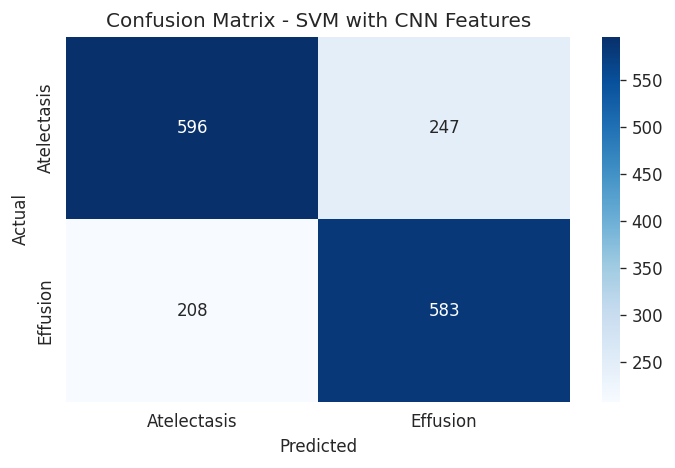

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM with CNN Features")
plt.tight_layout()
plt.show()

## SVM ROC curve

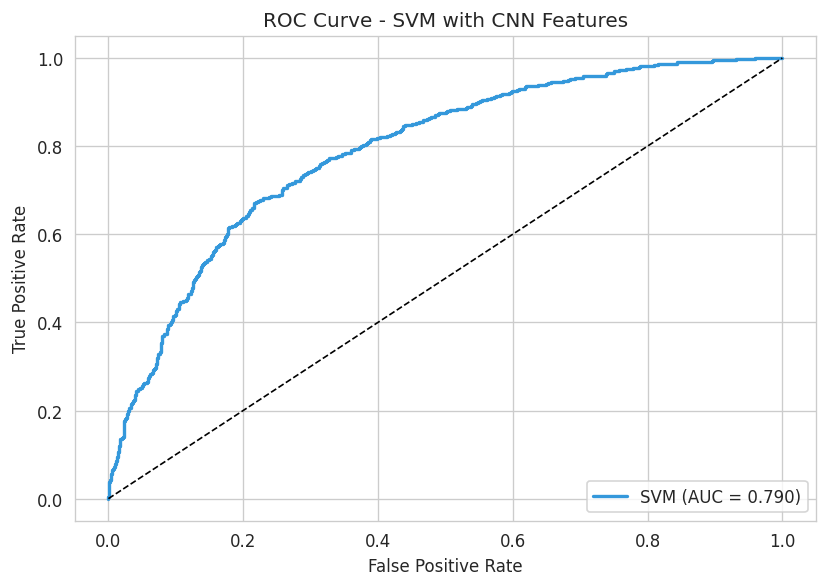

AUC: 0.7903


In [13]:
y_scores = svm_model.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f"SVM (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM with CNN Features")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(f"AUC: {auc:.4f}")

## GridSearch results summary

In [14]:
results_df = pd.DataFrame(grid.cv_results_)
results_df = results_df[['param_C', 'param_gamma', 'mean_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
print("GridSearchCV Results (sorted by rank):\n")
print(results_df.to_string(index=False))

GridSearchCV Results (sorted by rank):

 param_C param_gamma  mean_test_score  rank_test_score
   100.0       0.001         0.722671                1
    10.0       0.001         0.722671                1
     1.0        auto         0.721845                3
     1.0       scale         0.721845                3
    10.0        auto         0.718528                5
   100.0        auto         0.718528                5
    10.0       scale         0.718376                7
   100.0       scale         0.718376                7
     1.0       0.001         0.714563                9
     0.1       scale         0.680871               10
     0.1        auto         0.680871               10
     0.1       0.001         0.616414               12
    10.0        0.01         0.340299               13
     1.0        0.01         0.340299               13
   100.0        0.01         0.340299               13
     0.1        0.01         0.330845               16


## Train KNN (K=1 and K=27)

In [15]:
knn_1 = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn_1.fit(X_train_scaled, y_train)

knn_27 = KNeighborsClassifier(n_neighbors=27, n_jobs=-1)
knn_27.fit(X_train_scaled, y_train)

print("KNN training complete!")

KNN training complete!


##  KNN classification reports

In [16]:
y_pred_k1 = knn_1.predict(X_test_scaled)
y_pred_k27 = knn_27.predict(X_test_scaled)

print("=== KNN K=1 ===\n")
print(classification_report(y_test, y_pred_k1, target_names=le.classes_))

print("\n=== KNN K=27 ===\n")
print(classification_report(y_test, y_pred_k27, target_names=le.classes_))

=== KNN K=1 ===

              precision    recall  f1-score   support

 Atelectasis       0.64      0.70      0.67       843
    Effusion       0.65      0.59      0.62       791

    accuracy                           0.65      1634
   macro avg       0.65      0.64      0.64      1634
weighted avg       0.65      0.65      0.64      1634


=== KNN K=27 ===

              precision    recall  f1-score   support

 Atelectasis       0.64      0.78      0.70       843
    Effusion       0.70      0.53      0.60       791

    accuracy                           0.66      1634
   macro avg       0.67      0.66      0.65      1634
weighted avg       0.67      0.66      0.66      1634



## KNN confusion matrices side by side

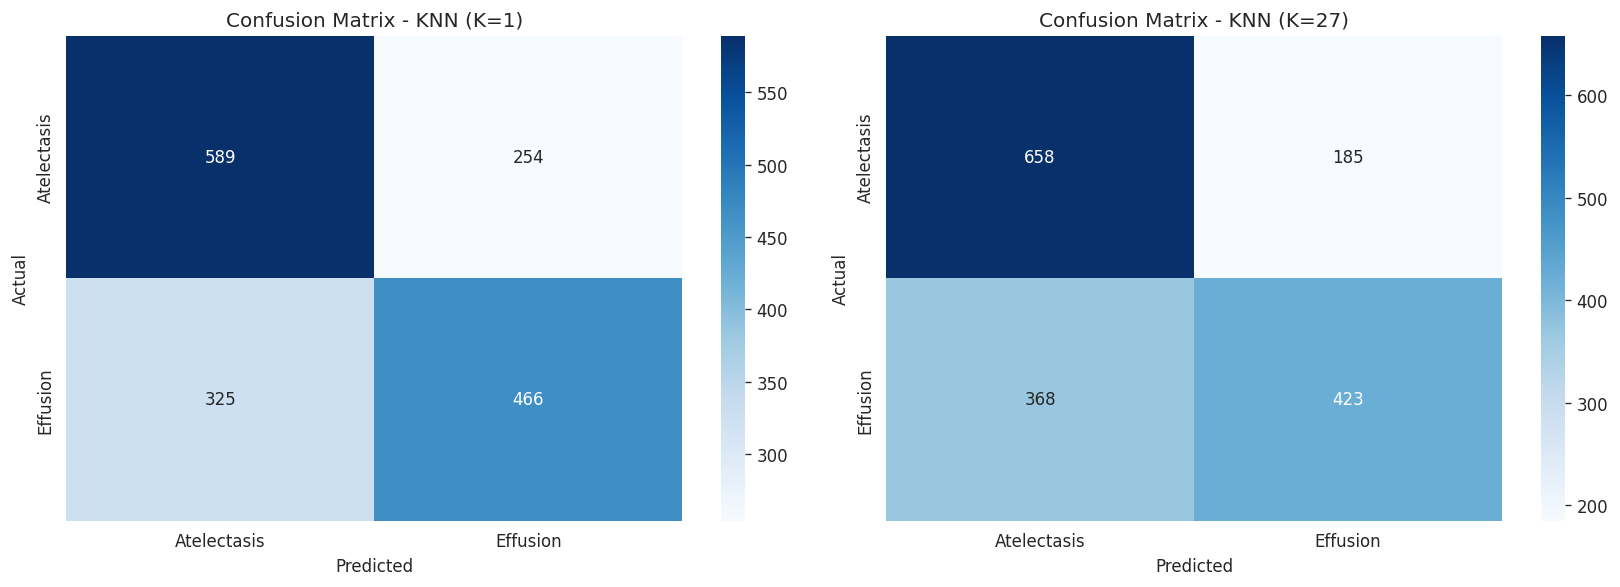

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, k in zip(axes, [y_pred_k1, y_pred_k27], [1, 27]):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - KNN (K={k})")

plt.tight_layout()
plt.show()

## KNN ROC curves

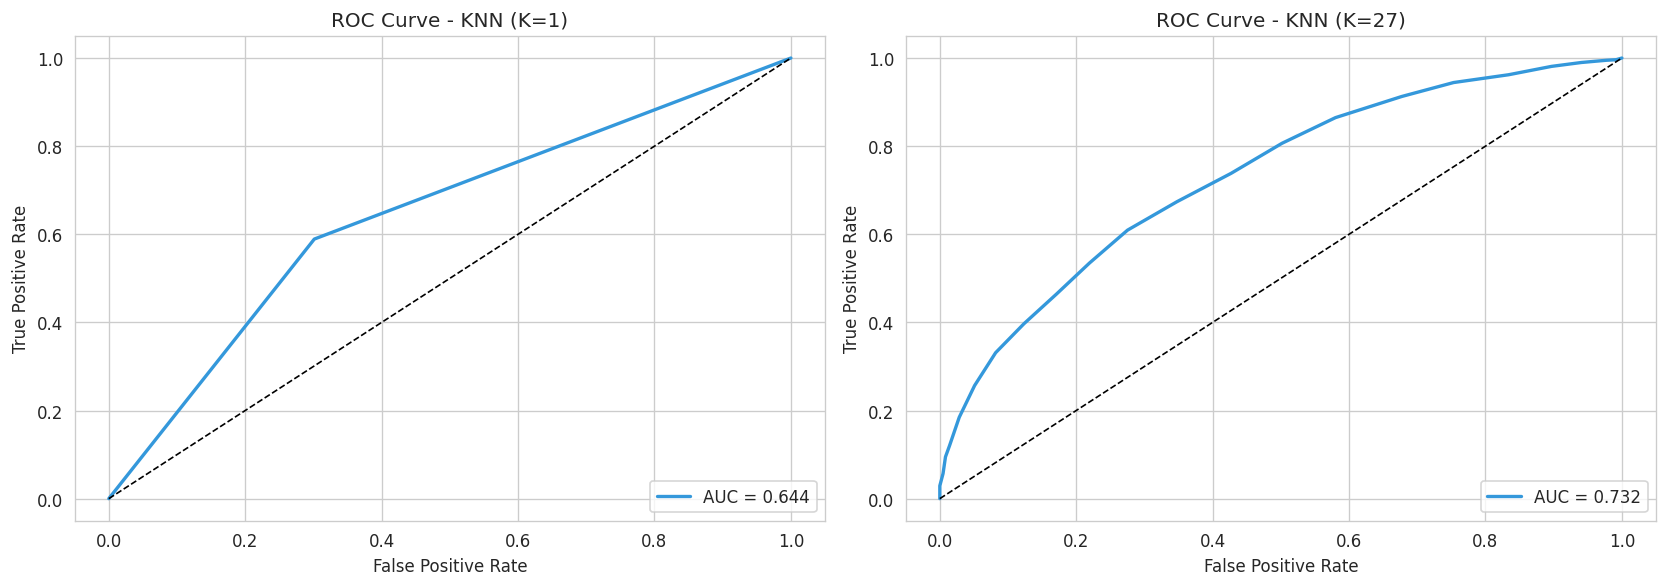

In [18]:
y_prob_k1 = knn_1.predict_proba(X_test_scaled)[:, 1]
y_prob_k27 = knn_27.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_sc, k in zip(axes, [y_prob_k1, y_prob_k27], [1, 27]):
    fpr, tpr, _ = roc_curve(y_test, y_sc)
    auc = roc_auc_score(y_test, y_sc)
    ax.plot(fpr, tpr, color='#3498db', lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - KNN (K={k})")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Compare all 3 models

In [19]:
y_scores_svm = svm_model.decision_function(X_test_scaled)

models = {
    "SVM (RBF)": (y_pred, y_scores_svm),
    "KNN (K=1)": (y_pred_k1, y_prob_k1),
    "KNN (K=27)": (y_pred_k27, y_prob_k27),
}

comparison = []
for name, (preds, scores) in models.items():
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    auc = roc_auc_score(y_test, scores)
    comparison.append({"Model": name, "Accuracy": acc, "F1 (macro)": f1, "AUC": auc})

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

     Model  Accuracy  F1 (macro)      AUC
 SVM (RBF)  0.721542    0.721525 0.790333
 KNN (K=1)  0.645655    0.643636 0.643911
KNN (K=27)  0.661567    0.654419 0.731863
